## Importieren aller Bibliotheken

In [2]:
# Fussbodenheizung - vorlauftemperatur absenken macht das system effizienter - raumtemp bleibt gleich - temp Bogen? wird geringer = COP wird verbessert - beeinflusst verhältnis von Wärme und strom - nutzen
#
import pypsa as ps
import pypsaheat as ph
import pandas as pd

C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


## Einlesen aller benötigten Daten

In [3]:
data = pd.read_excel('Uebung_01_data.xlsx', index_col='time')

### Hinzufügen einer Spalte zur Darstellung der Bodentemperatur

In [4]:
data['temp_ground'] = 10 #mit diesem Befehl wird eine Spalte hinzugefügt, die für alle Zeitpunkte den Wert 10 hat

<Axes: title={'center': 'Bodentemperatur über die Zeit'}, xlabel='Zeit', ylabel='Temperatur (°C)'>

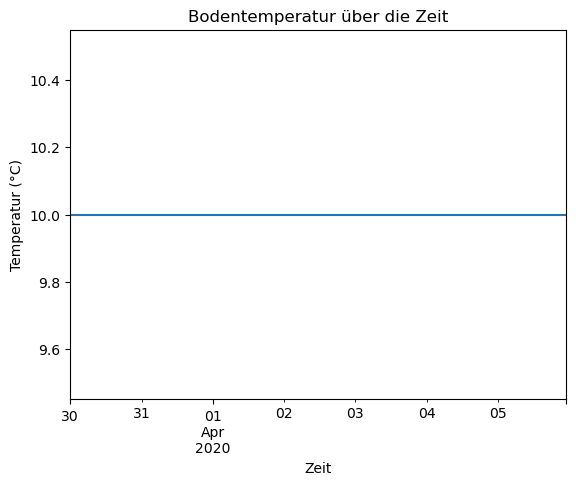

In [5]:
#Plotten der Bodentemperatur
data['temp_ground'].plot(title='Bodentemperatur über die Zeit', ylabel='Temperatur (°C)', xlabel='Zeit')

### Plotten der Daten

<Axes: title={'center': 'Stromverbrauch über die Zeit'}, xlabel='Zeit', ylabel='Leistung (kW)'>

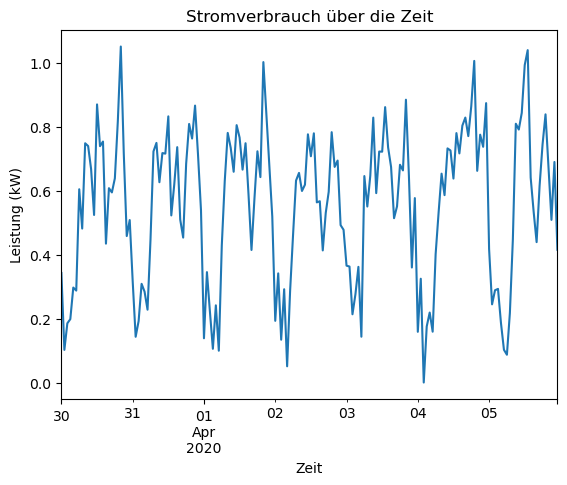

In [6]:
#Stromverbrauch allgemeiner Strom
data['electricity'].plot(title='Stromverbrauch über die Zeit', ylabel='Leistung (kW)', xlabel='Zeit')

<Axes: title={'center': 'Potentielle und normierte PV Erzeugung über die Zeit'}, xlabel='Zeit', ylabel='Leistung (kW)'>

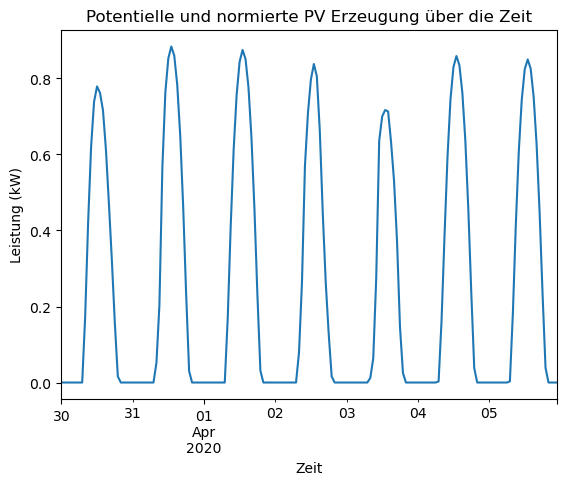

In [7]:
# PV Erzeugung
data['PV'].plot(title='Potentielle und normierte PV Erzeugung über die Zeit', ylabel='Leistung (kW)', xlabel='Zeit')

<Axes: title={'center': 'Außentemperatur über die Zeit'}, xlabel='Zeit', ylabel='Temperatur (°C)'>

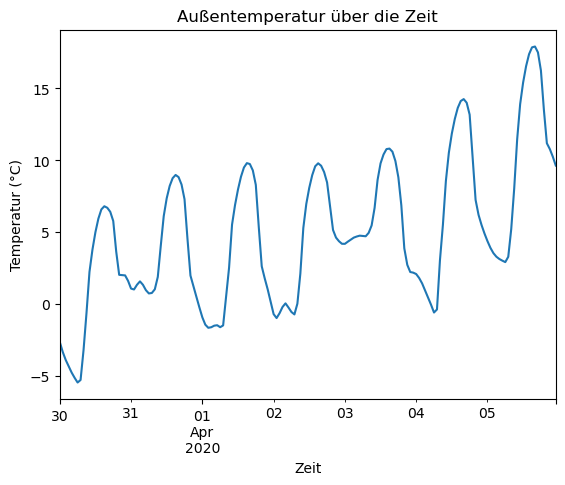

In [8]:
# Außentemperatur
data['temp'].plot(title='Außentemperatur über die Zeit', ylabel='Temperatur (°C)', xlabel='Zeit')

<Axes: title={'center': 'Raumwärmelast über die Zeit'}, xlabel='Zeit', ylabel='Wärmelast (kW)'>

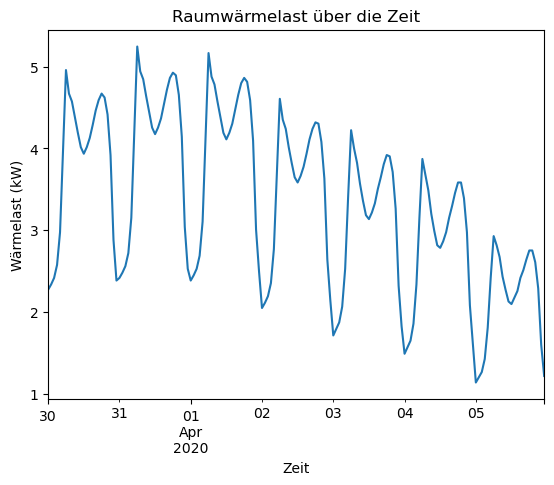

In [9]:
# Raumwärmelast
data['heat_space'].plot(title='Raumwärmelast über die Zeit', ylabel='Wärmelast (kW)', xlabel='Zeit')

<Axes: title={'center': 'Warmwasserlast über die Zeit'}, xlabel='Zeit', ylabel='Wärmelast (kW)'>

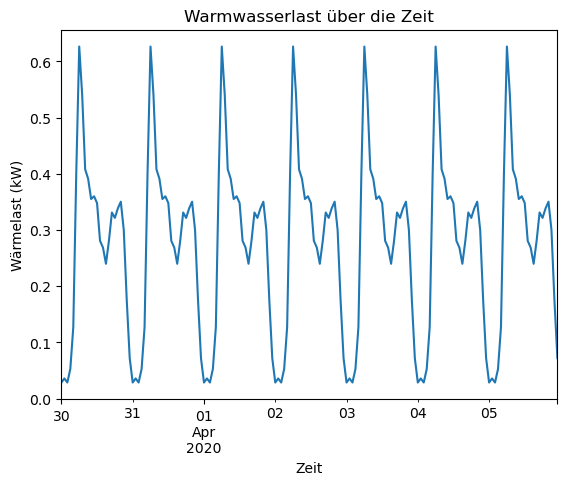

In [10]:
# Last für Warmwasser
data['heat_water'].plot(title='Warmwasserlast über die Zeit', ylabel='Wärmelast (kW)', xlabel='Zeit')

## Aufbau eine Energiesystems

### Auslegung der Komponenten

In [11]:
#Strom
PV_power = 5 # kWp
grid_power = 15 #kW Hausanschluss Leistung
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug

#Wärme
Store_height = 1.5 #m
Store_base = 0.4 #m² - Volumen ändern -
Store_T_layers = [60, 56, 52, 48, 44] #°C Temperaturschichten; !! Hier kann die Anzahl und die Temperatur der Schichten angepasst werden !! eckige KLammer = Liste [] ... für jede schicht wird rechenzeit erhöht - Volumenbleibt gleich  - Energieverbrauch sinkt -
Store_T_return = 40 #°C Rücklauftemperatur

HP_power = 6 #kW Wärmepumpenleistung
HE_power = 2 #kW Heizstableistung


### Berechnung des Vorlauftemperatur

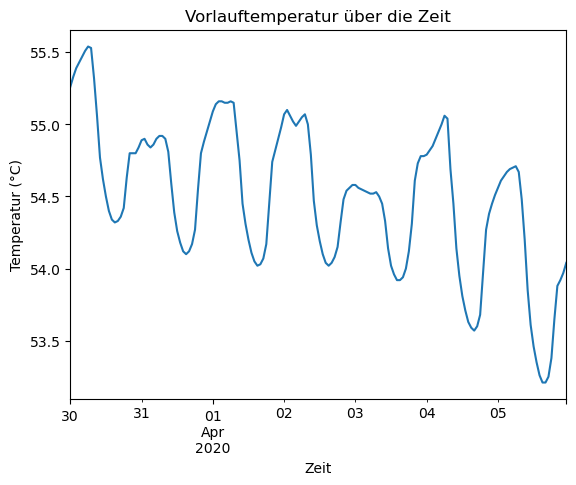

In [12]:
### Vorlauftemperatur für Heizsystem
T_at_0 = 55  #°C Vorlauftemperatur bei Außentemperatur 0°C; !! Hier kann die Vorlauftemperatur bei 0°C angepasst werden. Es ist auf die Temperaturschichten im Speicher zu achten !! - vorlauftemperatur kann ma absenken 45°C rücklauftemperatur müsste auch geringer sein - geringere Temp anforderung ans system - das bedeutet wir haben geringeren strom verbrauch - geringere kosten - immernoch 60°C warm wasser - dadurch bleiben kosten gleich - 60 grad müssen wir immernoch heizen - nach kosten optimierung - pv überschuss speichern und nutzen - immernoch 60 C wärme erzeugen und nicht 45 - auch wenn wir 45 benötigen - auf 60° kann man mehr wärme speichern - nach wie vor auf wärme speichern - speoicher kann damit größer beladen werden speicher temp und rücklauftemp - hier besser dann trotzdem höhere temp zu wählen - gedanken machen wie der wärmespeicher funktioniert und wie er dann arbeitet - welche sinnvollen speicherschichten kann ich annehmen - system versucht gesagmtkosten zu optimieren -
T_gradient = 0.1  #K/K Steigung der Heizkurve
aussentemperatur = data['temp']

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur) #Funktion zur Berechnung der Heizkurve
T_flow.plot(title='Vorlauftemperatur über die Zeit', ylabel='Temperatur (°C)', xlabel='Zeit')

#Anforderungstemperatur Warmwasser
T_Warmwasser = 60  #°C konstante Warmwassertemperatur

### Aufbau des Modells

In [19]:
## Ein pypsaheat Netzwerk erstellen
n = ph.HeatNetwork()

## Definieren der Simulationszeitschritte
n.set_snapshots(data.index)

###### Modellierung der elektrischen Seite ######

## Hinzufügen von Modellkomponenten
### Hinzufügen eines Knotens zur Strombilanzierung
n.add("Bus", 
      name = "electricity")
### Hinzufügen eines Generators zur Darstellung einer PV-Anlage 
n.add('Generator',
      name = 'PV',
      bus = 'electricity',
      p_nom = PV_power,
      p_max_pu = data['PV'])
### Hinzufügen eines Generators zur Darstellung des Netzbezugs
n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
      )
### Hinzufügen der elektrischen Last
n.add('Load', 
      bus = 'electricity',
      name = 'electricity_demand',
      p_set = data['electricity']
      )


###### Modellierung der Wärmeseite ######
## Hinzufügen von Modellkomponenten
# wenn nicht auf cyclic - es kann vorkommen das er mehr gefüllt wird als wir beziehen
#Hinzufügen eines Schichtspeichers mit konstanter Temperaturschichtung
n.add('HeatStore',
      name = 'hs',
      constant = 'temperature',           # constanter temperatur Ansatz
      height = Store_height, # Höhe in m
      base = Store_base, # Grundfläche in m²
      T_layer = Store_T_layers, #Temperaturschichten
      T_return = Store_T_return, #konstante Rücklauftemperatur
      cyclic = True,    # speicherinhalt am anfang und ende des zeitraums gleich sein muss
      U_wall = 0.2      # Wärmeverlust des speichers - Modelatributs - pypsa heat
      )

#Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power, # thermische Nennleistung in kW
      heat_store = 'hs',
      T_source = data['temp'], #Aussentemperatur als Wärmequelle; !! Hier kann die Temperatur der Abwärmequelle angepasst werden !! Temp_ground nehmen für ground temp Wärmepumpe
      T_max = 65, # °C
      heat_source  = 'air' #Luft als Wärmequelle; !! Hier kann die Abwärmequelle angepasst werden ('air' oder 'ground') !!
      )                       # kann man auch ground eingeben - COP ändert sich dann - Temperatur anpassen der Wärmequelle! momentan T_Außen muss aber zu T_ground sein
                              # Kostenberechnung kann man machen

#Hinzufügen eines Heizstabes an den Wärmespeicher
n.add('HeatingElement',
      name = 'he',
      bus0 = 'electricity',
      p_nom = HE_power, # elektrische Nennleistung in kW
      heat_store = 'hs', 
      efficiency = 0.95
      )

#Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = data['heat_space'], # Wärmelastgang
      T_demand = T_flow             # Temp anforderungen
      )

#Hinzufügen der Warmwasserlast
n.add('HeatLoad',
      name = 'heat_water_demand',
      heat_store = 'hs',
      p_set = data['heat_water'],
      T_demand = T_Warmwasser
      )

print(T_flow)
T_flow


time
2020-03-30 00:00:00    55.26
2020-03-30 01:00:00    55.33
2020-03-30 02:00:00    55.39
2020-03-30 03:00:00    55.43
2020-03-30 04:00:00    55.47
                       ...  
2020-04-05 19:00:00    53.65
2020-04-05 20:00:00    53.88
2020-04-05 21:00:00    53.92
2020-04-05 22:00:00    53.97
2020-04-05 23:00:00    54.04
Name: temp, Length: 168, dtype: float64


C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

time
2020-03-30 00:00:00    55.26
2020-03-30 01:00:00    55.33
2020-03-30 02:00:00    55.39
2020-03-30 03:00:00    55.43
2020-03-30 04:00:00    55.47
                       ...  
2020-04-05 19:00:00    53.65
2020-04-05 20:00:00    53.88
2020-04-05 21:00:00    53.92
2020-04-05 22:00:00    53.97
2020-04-05 23:00:00    54.04
Name: temp, Length: 168, dtype: float64

In [16]:
n.optimize(solver_name = 'gurobi')

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767106


INFO:gurobipy:Set parameter LicenseID to value 2767106


...

Solved in 1625 iterations and 0.06 seconds (0.02 work units)


INFO:gurobipy:Solved in 1625 iterations and 0.06 seconds (0.02 work units)


Optimal objective  6.098255336e+01


INFO:gurobipy:Optimal objective  6.098255336e+01
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3024 primals, 5880 duals
Objective: 6.10e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatingElement-he-fix-p-lower, HeatingElement-he-fix-p-upper, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 1
 - Generator: 2
 - Load: 1
 - HeatLoad: 2
 - HeatPump: 1
 - HeatStore: 1
 - HeatingElement: 1
Snapshots: 168

In [18]:
hs = "hs"
print("\n--- DEBUG: HeatStore im Network ---")
print("store_T_layers (python var):", Store_T_layers, "max:", max(Store_T_layers))

tl = n.heat_stores.loc[hs, "T_layer"]
print("n.heat_stores.T_layer raw:", tl)
print("type(T_layer):", type(tl))

# robust max bestimmen
if isinstance(tl, str):
    import ast
    tl_list = ast.literal_eval(tl)
else:
    tl_list = list(tl)

print("T_layer list:", tl_list, "max:", max(tl_list))

print("\n--- DEBUG: HeatLoad T_demand ---")
td = n.heat_loads.loc["Raumwaerme", "T_demand"]
print("type(T_demand):", type(td))

# wenn du T_demand als numpy array übergibst, ist es oft ein np.ndarray
td_max = np.nanmax(td) if hasattr(td, "__len__") else float(td)
print("T_demand max:", td_max)

print("\n--- CHECK ---")
print("T_demand max - max(T_layer) =", td_max - max(tl_list))



--- DEBUG: HeatStore im Network ---
store_T_layers (python var): [60, 56, 52, 48, 44] max: 60
n.heat_stores.T_layer raw: [60, 56, 52, 48, 44]
type(T_layer): <class 'list'>
T_layer list: [60, 56, 52, 48, 44] max: 60

--- DEBUG: HeatLoad T_demand ---


C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead

C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead

C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead

C:\Users\sarah\anaconda3\Lib\site-packages\

KeyError: 'Raumwaerme'

## Ergebnisse

### Speicherschichtung 

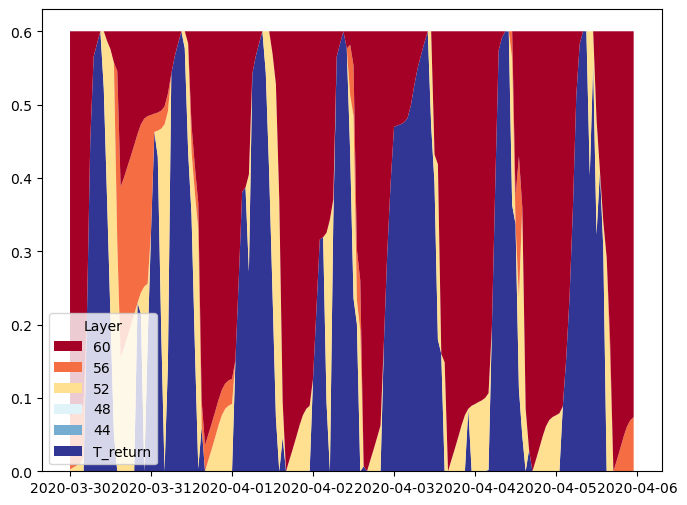

In [16]:
ph.plot.plot_stratified_heat_store(n, 'hs', sns = n.snapshots)

### Wärmelast

In [17]:
heat_demand_tot = round(n.heat_loads_t['p_set'].sum().sum(),2)
print(f'Der Gesamtwärmebedarf beträgt {heat_demand_tot} kWh.')

Der Gesamtwärmebedarf beträgt 610.08 kWh.


### Wärmepumpe

In [19]:
heat_prod_HP = round(n.heat_pumps_t['p_heat'].sum().sum(),2)
print(f'Die Gesamtwärmeproduktion der Wärmepumpe beträgt {heat_prod_HP} kWh.')

Die Gesamtwärmeproduktion der Wärmepumpe beträgt 577.65 kWh.


In [20]:
elec_cons_HP = round(n.heat_pumps_t['p_elec'].sum().sum(),2)
print(f'Der gesamte Strombezug der Wärmepumpe beträgt {elec_cons_HP} kWh.')

Der gesamte Strombezug der Wärmepumpe beträgt 233.04 kWh.


In [21]:
print(f'Das Verhältnis von Wärmeproduktion der Wärmepumpe zu ihrem Stromverbrauch beträgt {round(heat_prod_HP/elec_cons_HP,2)}.') # COP

Das Verhältnis von Wärmeproduktion der Wärmepumpe zu ihrem Stromverbrauch beträgt 2.48.


### Heizelement 

In [22]:
heat_prod_HE = round(n.heating_elements_t['p_heat'].sum().sum(),2) #
print(f'Die Gesamtwärmeproduktion des Heizstabes beträgt {heat_prod_HE} kWh.')

Die Gesamtwärmeproduktion des Heizstabes beträgt 36.06 kWh.


In [23]:
elec_cons_HE = round(n.heating_elements_t['p_elec'].sum().sum(),2)
print(f'Der gesamte Strombezug des Heizelement beträgt {elec_cons_HE} kWh.') # Effizienzverlust - 5%

Der gesamte Strombezug des Heizelement beträgt 37.96 kWh.


### Gesamte Wärmeerzeugung

In [24]:
print(f'Die Gesamtwärmeproduktion beträgt {heat_prod_HP + heat_prod_HE} kWh.') #

Die Gesamtwärmeproduktion beträgt 613.71 kWh.


In [25]:
print(f'Die Gesamtwärmeproduktion ist {round(((heat_prod_HP + heat_prod_HE)/heat_demand_tot - 1)*100,2)}% größer als der Gesamtwärmeverbrauch.')

Die Gesamtwärmeproduktion ist 0.6% größer als der Gesamtwärmeverbrauch.


### PV Erzeugung

In [26]:
PV_generation = n.generators_t.p['PV'].sum()
print(f'Die gesamte PV-Erzeugung beträgt {round(PV_generation,2)} kWh.')

Die gesamte PV-Erzeugung beträgt 205.08 kWh.


### Netzbezug

In [27]:
grid_generation = n.generators_t.p['grid'].sum()
print(f'Der gesamte Netzbezug beträgt {round(grid_generation,2)} kWh.')

Der gesamte Netzbezug beträgt 159.11 kWh.


### Netzbezugkosten

In [28]:
grid_costs = grid_generation * n.generators.loc['grid', 'marginal_cost']
print(f'Die Gesamtkosten für den Netzbezug betragen {round(grid_costs,2)}€.')

Die Gesamtkosten für den Netzbezug betragen 55.69€.
